In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time
import functools

import os
import pathlib

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
NOTEBOOK_DIR = pathlib.Path().resolve()

CHROMA_PATH = NOTEBOOK_DIR / "chroma_db"

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-miniLM-L6-v2")

if (CHROMA_PATH / "chroma.sqlite3").exists():
    print("Loading existing vector store from disk...")
    vector_store = Chroma(
        collection_name="rag_collection",
        embedding_function=embeddings,
        persist_directory=str(CHROMA_PATH),
    )
else:
    print("Loading PDFs, chunking, and creating vector store...")
    docs = (
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "Company_Policies.pdf").load() +
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "Company_Profile.pdf").load() +
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "Product_and_Pricing.pdf").load()
    )
    chunks = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=150).split_documents(docs)
    for d in chunks:
        d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

    vector_store = Chroma(
        collection_name="rag_collection",
        embedding_function=embeddings,
        persist_directory=str(CHROMA_PATH),
    )
    for i in range(0, len(chunks), 1000):
        vector_store.add_documents(chunks[i:i+1000])
        print(f"Indexed Batch {i}")
    print(f"Indexed {len(chunks)} chunks.")

Loading existing vector store from disk...


In [3]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 4})

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.environ["GROQ_API_KEY"],
    request_timeout=60,
)

In [5]:
def retry(max_attempts: int = 10, wait: int = 10):
    def deco(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            name = func.__name__
            print(f"[{time.strftime('%H:%M:%S')}] START {name}")
            t0 = time.perf_counter()
            for attempt in range(max_attempts):
                try:
                    result = func(*args, **kwargs)
                    elapsed = time.perf_counter() - t0
                    print(f"[{time.strftime('%H:%M:%S')}] END {name} ({elapsed:.2f}s)")
                    return result
                except Exception as e:
                    if attempt == max_attempts - 1:
                        elapsed = time.perf_counter() - t0
                        print(f"[{time.strftime('%H:%M:%S')}] FAILED {name} ({elapsed:.2f}s)")
                        raise
                    ts = time.strftime("%H:%M:%S")
                    print(f"[{name}] {ts} attempt {attempt + 1}/{max_attempts} failed: {e}. retry in {wait}s...")
                    time.sleep(wait)
        return wrapper
    return deco

In [6]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str

In [7]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

@retry()
def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [8]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


@retry()
def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [9]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [10]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

@retry()
def _judge_relevance(question: str, document: str) -> RelevanceDecision:
    return relevance_llm.invoke(
        is_relevant_prompt.format_messages(question=question, document=document)
    )

def is_relevant(state: State):
    relevant_docs: List[Document] = []
    for doc in state["docs"]:
        decision = _judge_relevance(state["question"], doc.page_content)
        if decision.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

In [11]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

@retry()
def generate_from_context(state: State):
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}

In [12]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [13]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm = llm.with_structured_output(IsSUPDecision)

@retry()
def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}


MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    if state.get("issup") == "fully_supported":
        return "accept_answer"
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"
    return "revise_answer"

In [14]:
def accept_answer(state: State):
    return {}

In [15]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

@retry()
def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,
    }

In [16]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

@retry()
def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}


def route_after_isuse(state: State) -> Literal["END", "no_relevant_docs"]:
    if state.get("isuse") == "useful":
        return "END"
    return "no_relevant_docs"

In [17]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [18]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_relevant_docs"

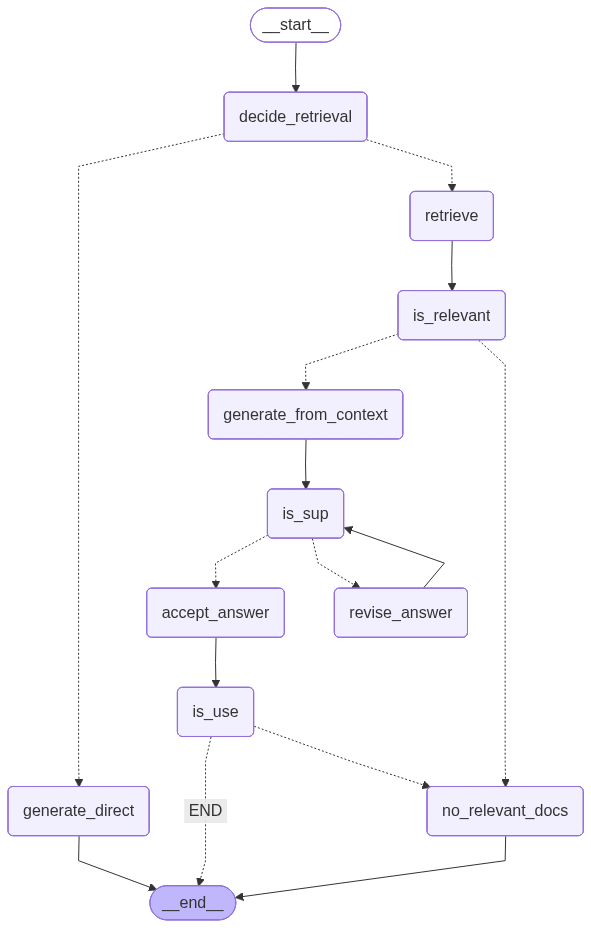

In [19]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)
g.add_node("is_sup", is_sup)
g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)
g.add_node("is_use", is_use)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_relevant_docs": "no_relevant_docs",
    },
)

g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "accept_answer",
        "revise_answer": "revise_answer",
    },
)

g.add_edge("revise_answer", "is_sup")
g.add_edge("accept_answer", "is_use")

g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "no_relevant_docs": "no_relevant_docs",
    },
)

g.add_edge("no_relevant_docs", END)

app = g.compile()
app

In [24]:
result = app.invoke(
    {
        "question": "Describe NexaAI's company culture.",
        "need_retrieval": False,
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": [],
        "retries": 0,
        "isuse": "",
        "use_reason": "",
    },
    config={"recursion_limit": 80},
)

print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("retries:", result.get("retries"))
print("isuse:", result.get("isuse"))
print("use_reason:", result.get("use_reason"))
print("answer:", result.get("answer"))

from IPython.display import Markdown, display
content = result["answer"]
if isinstance(content, list):
    content = "".join(block.get("text", "") for block in content if isinstance(block, dict) and block.get("type") == "text")
display(Markdown(content))

[14:03:03] START decide_retrieval
[14:03:04] END decide_retrieval (0.53s)
[14:03:04] START _judge_relevance
[14:03:04] END _judge_relevance (0.33s)
[14:03:04] START _judge_relevance
[14:03:05] END _judge_relevance (0.51s)
[14:03:05] START _judge_relevance
[14:03:05] END _judge_relevance (0.25s)
[14:03:05] START _judge_relevance
[14:03:05] END _judge_relevance (0.33s)
[14:03:05] START generate_from_context
[14:03:06] END generate_from_context (0.65s)
[14:03:06] START is_sup
[14:03:06] END is_sup (0.55s)
[14:03:06] START revise_answer
[14:03:07] END revise_answer (0.51s)
[14:03:07] START is_sup
[14:03:07] END is_sup (0.47s)
[14:03:07] START is_use
[14:03:08] END is_use (0.41s)
need_retrieval: True
#docs: 4
#relevant_docs: 1
issup: fully_supported
evidence: ['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'Employees are encouraged to maintain a healthy work-life balance.', 'All employment decisions are made without discrimination']
retries: 1
isu

- NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- Employees are encouraged to maintain a healthy work-life balance.

In [25]:
result['need_retrieval']

True

In [26]:
result['docs']

[Document(id='e39333ae-3ba6-4d8d-9602-065838f0a5f7', metadata={'trapped': '/False', 'page': 0, 'producer': 'ReportLab PDF Library - www.reportlab.com', 'subject': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'moddate': '2026-02-14T13:07:17+00:00', 'source': 'G:\\Other computers\\My Laptop\\IT Return related docs\\Suvam Learning and Training notes\\007_genAI\\03_LangGraph_and_Langsmith_and_LLMOps\\Project\\LangGraph_basics\\module_28_self_reflection_RAG\\documents\\Company_Profile.pdf', 'total_pages': 2, 'author': '(anonymous)', 'creator': '(unspecified)', 'page_label': '1', 'title': '(anonymous)', 'keywords': ''}, page_content='NexaAI Solutions – Company Profile\nCompany Overview\nNexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.\nThe company specializes in building enterprise-ready AI systems for knowledge management,\nanalytics, and automation.\nNexaAI primarily serves mid-sized and large organizations across technology

In [27]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

****************************************************************************************************
